Kacper Kaszuba
Dataset:
https://datadryad.org/dataset/doi:10.5061/dryad.bp26v20

### Description:

Dataset
**PHYLACINE 1.2** — The Phylogenetic Atlas of Mammal Macroecology
- 5,831 known mammal species
- Two key files:
  - `Trait_data.csv` — body mass (`Mass.g`), diet, habitat type, taxonomic order, IUCN status (`IUCN.Status.1.2`)
  - `Spatial_metadata.csv` — geographic range size (`Number.Cells.Current.Range`, `Number.Cells.Present.Natural.Range`)
- Files are merged on `Binomial.1.2` (species name)

### Thesis
> **"Body mass and geographic range size are the dominant biological predictors of extinction risk in mammals, independent of taxonomic order."**

This thesis is confronted using **Random Forest feature importance** — if `Log.Mass` and `Log.Range.Current` rank highest, thesis is confirmed. If `Order.Encoded` (taxonomic order) ranks high, it suggests taxonomy matters more than claimed.

**A taxonomic class** is a major biological classification rank, sitting between phylum and order

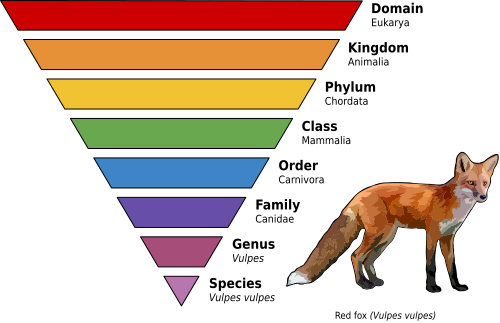

Source: https://en.wikipedia.org/wiki/Taxonomic_rank

 image link: https://upload.wikimedia.org/wikipedia/commons/thumb/7/71/Taxonomic_Rank_Graph.svg/500px-Taxonomic_Rank_Graph.svg.png

In [5]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML — preprocessing & classical models
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight

# Neural Network
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Optional but useful
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

Loading Dataset

In [6]:
trait = pd.read_csv('Trait_data.csv')
spatial = pd.read_csv('Spatial_metadata.csv')

In [7]:
display(trait.shape)
display(spatial.shape)

(5831, 24)

(5831, 12)

In [8]:
trait_set = set(trait['Binomial.1.2'])
spatial_set = set(spatial['Binomial.1.2'])

if trait_set == spatial_set:
  print("they are equal")
else:
  print("not equal")

they are equal


In [9]:
print(f"trait lenght:  {len(trait_set)}")
print(f"spatial lenght:  {len(spatial_set)}")

trait lenght:  5831
spatial lenght:  5831


After this check, we know that the species in both tables are the same, so we can merge them

In [10]:
trait.head(5)

,Binomial.1.2,Order.1.2,Family.1.2,Genus.1.2,Species.1.2,Terrestrial,Marine,Freshwater,Aerial,Life.Habit.Method,...,Mass.Comparison,Mass.Comparison.Source,Island.Endemicity,IUCN.Status.1.2,Added.IUCN.Status.1.2,Diet.Plant,Diet.Vertebrate,Diet.Invertebrate,Diet.Method,Diet.Source
0,Abditomys_latidens,Rodentia,Muridae,Abditomys,latidens,1,0,0,0,Reported,...,NaN,NaN,Occurs only on isolated islands,DD,No,100,0,0,Reported 000 Species,"Wilman, H., et al. 2014. EltonTraits 1.0: spec..."
1,Abeomelomys_sevia,Rodentia,Muridae,Abeomelomys,sevia,1,0,0,0,Reported,...,NaN,NaN,Occurs on large land bridge islands,LC,No,78,3,19,Imputed 000 Species,PHYLACINE 1.2
2,Abrawayaomys_ruschii,Rodentia,Cricetidae,Abrawayaomys,ruschii,1,0,0,0,Reported,...,NaN,NaN,Occurs on mainland,LC,No,88,1,11,Imputed 000 Species,PHYLACINE 1.2
3,Abrocoma_bennettii,Rodentia,Abrocomidae,Abrocoma,bennettii,1,0,0,0,Reported,...,NaN,NaN,Occurs on mainland,LC,No,100,0,0,Reported 000 Species,"Wilman, H., et al. 2014. EltonTraits 1.0: spec..."
4,Abrocoma_boliviensis,Rodentia,Abrocomidae,Abrocoma,boliviensis,1,0,0,0,Reported,...,NaN,NaN,Occurs on mainland,CR,No,100,0,0,Reported 000 Species,"Wilman, H., et al. 2014. EltonTraits 1.0: spec..."


In [11]:
spatial.head(5)

,Binomial.1.2,Order.1.2,Family.1.2,Genus.1.2,Species.1.2,Certainty.Level,Modification,Motivation,Last.Manual.Present.Natural.Modification,Number.Cells.Current.Range,Number.Cells.Present.Natural.Range,Change.In.Cells
0,Abditomys_latidens,Rodentia,Muridae,Abditomys,latidens,3) Merger of likely human caused disjunct rang...,Connected via ecoregion.,Disjunct range likely anthropogenic in cause.,Version 1.0,5,9,4
1,Abeomelomys_sevia,Rodentia,Muridae,Abeomelomys,sevia,0) Present Natural range identical to IUCN range,NaN,NaN,NaN,10,10,0
2,Abrawayaomys_ruschii,Rodentia,Cricetidae,Abrawayaomys,ruschii,0) Present Natural range identical to IUCN range,NaN,NaN,NaN,20,20,0
3,Abrocoma_bennettii,Rodentia,Abrocomidae,Abrocoma,bennettii,0) Present Natural range identical to IUCN range,NaN,NaN,NaN,28,28,0
4,Abrocoma_boliviensis,Rodentia,Abrocomidae,Abrocoma,boliviensis,0) Present Natural range identical to IUCN range,NaN,NaN,NaN,1,1,0


In [12]:
spatial_to_merge  =  spatial[["Binomial.1.2", 'Number.Cells.Current.Range', 'Number.Cells.Present.Natural.Range']]

In [13]:
trait_merged =  pd.merge(trait, spatial_to_merge, how='left',  on='Binomial.1.2')
trait_merged.head(5)

,Binomial.1.2,Order.1.2,Family.1.2,Genus.1.2,Species.1.2,Terrestrial,Marine,Freshwater,Aerial,Life.Habit.Method,...,Island.Endemicity,IUCN.Status.1.2,Added.IUCN.Status.1.2,Diet.Plant,Diet.Vertebrate,Diet.Invertebrate,Diet.Method,Diet.Source,Number.Cells.Current.Range,Number.Cells.Present.Natural.Range
0,Abditomys_latidens,Rodentia,Muridae,Abditomys,latidens,1,0,0,0,Reported,...,Occurs only on isolated islands,DD,No,100,0,0,Reported 000 Species,"Wilman, H., et al. 2014. EltonTraits 1.0: spec...",5,9
1,Abeomelomys_sevia,Rodentia,Muridae,Abeomelomys,sevia,1,0,0,0,Reported,...,Occurs on large land bridge islands,LC,No,78,3,19,Imputed 000 Species,PHYLACINE 1.2,10,10
2,Abrawayaomys_ruschii,Rodentia,Cricetidae,Abrawayaomys,ruschii,1,0,0,0,Reported,...,Occurs on mainland,LC,No,88,1,11,Imputed 000 Species,PHYLACINE 1.2,20,20
3,Abrocoma_bennettii,Rodentia,Abrocomidae,Abrocoma,bennettii,1,0,0,0,Reported,...,Occurs on mainland,LC,No,100,0,0,Reported 000 Species,"Wilman, H., et al. 2014. EltonTraits 1.0: spec...",28,28
4,Abrocoma_boliviensis,Rodentia,Abrocomidae,Abrocoma,boliviensis,1,0,0,0,Reported,...,Occurs on mainland,CR,No,100,0,0,Reported 000 Species,"Wilman, H., et al. 2014. EltonTraits 1.0: spec...",1,1


In [14]:
display(trait_merged.shape)
display(trait_merged.describe())
display(trait_merged.info())

(5831, 26)

,Terrestrial,Marine,Freshwater,Aerial,Mass.g,Diet.Plant,Diet.Vertebrate,Diet.Invertebrate,Number.Cells.Current.Range,Number.Cells.Present.Natural.Range
count,5831.000000,5831.000000,5831.000000,5831.000000,5.831000e+03,5831.000000,5831.000000,5831.000000,5831.000000,5831.000000
mean,0.784600,0.023152,0.026582,0.199280,1.570861e+05,56.461327,9.075973,34.462699,341.547076,379.215572
std,0.411135,0.150399,0.160872,0.399493,3.145802e+06,43.241440,20.641177,38.551807,1922.439625,1929.320214
min,0.000000,0.000000,0.000000,0.000000,1.600000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,2.100000e+01,0.000000,0.000000,0.000000,6.000000,11.000000
50%,1.000000,0.000000,0.000000,0.000000,8.440000e+01,80.000000,0.000000,20.000000,39.000000,52.000000
75%,1.000000,0.000000,0.000000,0.000000,9.924000e+02,100.000000,4.000000,70.000000,188.000000,226.500000
max,1.000000,1.000000,1.000000,1.000000,1.900000e+08,100.000000,100.000000,100.000000,37542.000000,37542.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5831 entries, 0 to 5830
Data columns (total 26 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Binomial.1.2                        5831 non-null   object 
 1   Order.1.2                           5831 non-null   object 
 2   Family.1.2                          5831 non-null   object 
 3   Genus.1.2                           5831 non-null   object 
 4   Species.1.2                         5831 non-null   object 
 5   Terrestrial                         5831 non-null   int64  
 6   Marine                              5831 non-null   int64  
 7   Freshwater                          5831 non-null   int64  
 8   Aerial                              5831 non-null   int64  
 9   Life.Habit.Method                   5831 non-null   object 
 10  Life.Habit.Source                   5831 non-null   object 
 11  Mass.g                              5831 no

None

 Building a Binary Target on a Column `IUCN.Status.1.2`

In [15]:
trait_merged['IUCN.Status.1.2'].drop_duplicates()

,IUCN.Status.1.2
0,DD
1,LC
4,CR
17,NT
18,VU
19,EN
45,EP
413,EX
1486,EW


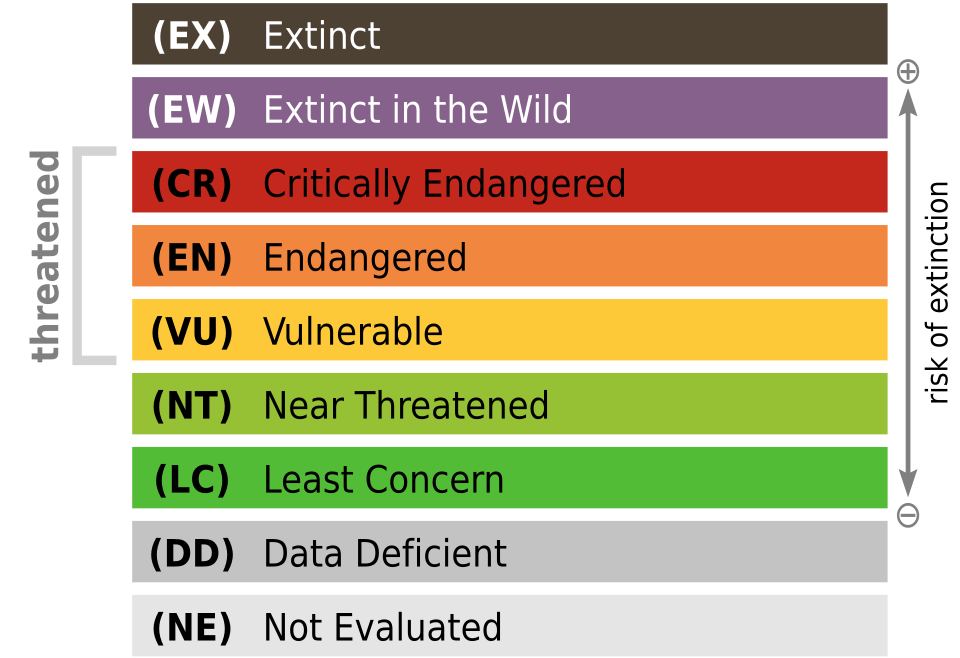

Source: https://commons.wikimedia.org/wiki/File:Status_iucn3.1.svg

 image link: https://upload.wikimedia.org/wikipedia/commons/thumb/3/36/IUCN_Kategorien_Rote_Liste.svg/960px-IUCN_Kategorien_Rote_Liste.svg.png

In [16]:
trait_merged['IUCN.Status.1.2'].value_counts()

,count
IUCN.Status.1.2,
LC,3157
DD,777
VU,525
EN,464
NT,350
EP,270
CR,204
EX,82
EW,2


**IUCN** It matches the table from the internet

The authors added the status `EP`, which means “extinct in prehistory.”

To avoid cluttering the results, we will remove the following columns: `DD, EP, EX, EW`

Binary Classification:
- **0 — Not threatened:** LC (Least Concern), NT (Near Threatened)
- **1 — Threatened:** VU (Vulnerable), EN (Endangered), CR (Critically Endangered)

In [17]:
keep_categories =  ['LC',  'NT', 'VU', 'EN', 'CR']

#  Filtering
trait_merged  = trait_merged[trait_merged['IUCN.Status.1.2'].isin(keep_categories)]
trait_merged.head()

,Binomial.1.2,Order.1.2,Family.1.2,Genus.1.2,Species.1.2,Terrestrial,Marine,Freshwater,Aerial,Life.Habit.Method,...,Island.Endemicity,IUCN.Status.1.2,Added.IUCN.Status.1.2,Diet.Plant,Diet.Vertebrate,Diet.Invertebrate,Diet.Method,Diet.Source,Number.Cells.Current.Range,Number.Cells.Present.Natural.Range
1,Abeomelomys_sevia,Rodentia,Muridae,Abeomelomys,sevia,1,0,0,0,Reported,...,Occurs on large land bridge islands,LC,No,78,3,19,Imputed 000 Species,PHYLACINE 1.2,10,10
2,Abrawayaomys_ruschii,Rodentia,Cricetidae,Abrawayaomys,ruschii,1,0,0,0,Reported,...,Occurs on mainland,LC,No,88,1,11,Imputed 000 Species,PHYLACINE 1.2,20,20
3,Abrocoma_bennettii,Rodentia,Abrocomidae,Abrocoma,bennettii,1,0,0,0,Reported,...,Occurs on mainland,LC,No,100,0,0,Reported 000 Species,"Wilman, H., et al. 2014. EltonTraits 1.0: spec...",28,28
4,Abrocoma_boliviensis,Rodentia,Abrocomidae,Abrocoma,boliviensis,1,0,0,0,Reported,...,Occurs on mainland,CR,No,100,0,0,Reported 000 Species,"Wilman, H., et al. 2014. EltonTraits 1.0: spec...",1,1
6,Abrocoma_cinerea,Rodentia,Abrocomidae,Abrocoma,cinerea,1,0,0,0,Reported,...,Occurs on mainland,LC,No,100,0,0,Reported 000 Species,"Wilman, H., et al. 2014. EltonTraits 1.0: spec...",82,82


In [18]:
trait_merged['IUCN.Status.1.2'].value_counts()

,count
IUCN.Status.1.2,
LC,3157
VU,525
EN,464
NT,350
CR,204


In [19]:
trait_merged.shape[0]

4700

The result matches `3157+350+525+464+204 = 4700`

In [20]:
# Creating Threatened  column (0/1)
trait_merged["Threatened"] = trait_merged['IUCN.Status.1.2'].isin(['VU', 'EN', 'CR']).astype(int)
trait_merged["Threatened"]

,Threatened
1,0
2,0
3,0
4,1
6,0
...,...
5826,0
5827,1
5828,1
5829,1


In [21]:
trait_merged["Threatened"].value_counts()

,count
Threatened,
0,3507
1,1193


In [22]:
display(trait_merged["Mass.g"].min())
display(trait_merged["Number.Cells.Current.Range"].min())
display(trait_merged["Number.Cells.Present.Natural.Range"].min())


1.6

0

0

As you can see, the values for `Number.Cells.Current.Range` and `Number.Cells.Present.Natural.Range` can be `0`, so in the next step we'll use `log1p`, because it won't throw an error when `0` occurs, and it works better than `log` for small values

Next, we need to take the logarithm of the `Mass.g` column to remove the weight bias. If we skipped this step, the small mammals—which make up a significant portion of the dataset—would be overshadowed by cases with high weights.  The logarithm solves this problem because it “compresses” large weights and “stretches” small ones.

In [23]:
# Creating 3 new columns Log.Mass, Log.Range.Current, Log.Range.Natural
trait_merged["Log.Mass"] = np.log1p(trait_merged["Mass.g"])
trait_merged["Log.Range.Current"] = np.log1p(trait_merged["Number.Cells.Current.Range"])
trait_merged["Log.Range.Natural"] = np.log1p(trait_merged["Number.Cells.Present.Natural.Range"])

In [24]:
display(trait_merged["Log.Mass"])
display(trait_merged["Log.Range.Current"])
display(trait_merged["Log.Range.Natural"])

,Log.Mass
1,3.970292
2,4.158883
3,5.525453
4,5.068904
6,5.525453
...,...
5826,3.610918
5827,4.553877
5828,4.820282
5829,4.615121


,Log.Range.Current
1,2.397895
2,3.044522
3,3.367296
4,0.693147
6,4.418841
...,...
5826,5.365976
5827,2.564949
5828,1.386294
5829,1.386294


,Log.Range.Natural
1,2.397895
2,3.044522
3,3.367296
4,0.693147
6,4.418841
...,...
5826,5.365976
5827,2.564949
5828,1.386294
5829,3.496508


Checking the diference

In [25]:
display(trait_merged["Log.Mass"].describe())
display(trait_merged["Mass.g"].describe())

,Log.Mass
count,4700.000000
mean,5.121728
std,2.726751
min,0.955511
25%,3.072693
50%,4.359909
75%,6.708236
max,19.062535


,Mass.g
count,4.700000e+03
mean,1.284192e+05
std,3.421710e+06
min,1.600000e+00
25%,2.060000e+01
50%,7.725000e+01
75%,8.181250e+02
max,1.900000e+08


In [26]:
display(trait_merged["Log.Range.Current"].describe())
display(trait_merged["Number.Cells.Current.Range"].describe())

,Log.Range.Current
count,4700.000000
mean,4.092058
std,1.859333
min,0.000000
25%,2.708050
50%,4.127134
75%,5.472271
max,10.514014


,Number.Cells.Current.Range
count,4700.000000
mean,331.738511
std,1706.740123
min,0.000000
25%,14.000000
50%,61.000000
75%,237.000000
max,36827.000000


In [27]:
display(trait_merged["Log.Range.Natural"].describe())
display(trait_merged["Number.Cells.Present.Natural.Range"].describe())

,Log.Range.Natural
count,4700.000000
mean,4.189782
std,1.822820
min,0.000000
25%,2.833213
50%,4.189655
75%,5.529429
max,10.514014


,Number.Cells.Present.Natural.Range
count,4700.000000
mean,347.898085
std,1709.874818
min,0.000000
25%,16.000000
50%,65.000000
75%,251.000000
max,36827.000000


As you can see, the `log1p` operation was successful. Based on `Mass.g` and `Log.Mass`, we can see that for `Mass.g`, `mean ≈ 128,419`, but `std ≈ 3,421,710`—the standard deviation is 27 times greater than the mean. This is exactly what I mentioned above: a single outlier significantly skews the scale. In contrast, for `Log.Mass`, `mean ≈ 5.12` and `std ≈ 2.73`; in this case, the standard deviation is smaller than the mean, and the distribution looks much better than before.
You can also see that in `Mass.g`, `75%` is 818g and `max` is 190,000,000g. After taking the log, `75% = 6.7` and `max = 19.06`.

In [28]:
trait_merged['Order.1.2'].value_counts()

,count
Order.1.2,
Rodentia,1862
Chiroptera,952
Primates,417
Eulipotyphla,373
Carnivora,283
Cetartiodactyla,260
Diprotodontia,139
Lagomorpha,87
Didelphimorphia,81


In [29]:
le = LabelEncoder()
trait_merged["Order.Encoded"] = le.fit_transform(trait_merged['Order.1.2'])
display(trait_merged["Order.Encoded"])
print(f"Category Mapping: {le.classes_}")

,Order.Encoded
1,23
2,23
3,23
4,23
6,23
...,...
5826,23
5827,23
5828,23
5829,23


Category Mapping: ['Afrosoricida' 'Carnivora' 'Cetartiodactyla' 'Chiroptera' 'Cingulata'
 'Dasyuromorphia' 'Dermoptera' 'Didelphimorphia' 'Diprotodontia'
 'Eulipotyphla' 'Hyracoidea' 'Lagomorpha' 'Macroscelidea' 'Microbiotheria'
 'Monotremata' 'Notoryctemorphia' 'Paucituberculata' 'Peramelemorphia'
 'Perissodactyla' 'Pholidota' 'Pilosa' 'Primates' 'Proboscidea' 'Rodentia'
 'Scandentia' 'Sirenia' 'Tubulidentata']


In [30]:
display(trait_merged["Order.Encoded"].value_counts())

,count
Order.Encoded,
23,1862
3,952
21,417
9,373
1,283
2,260
8,139
11,87
7,81


In [31]:
data_to_check = trait_merged[['Log.Mass', 'Log.Range.Current', 'Log.Range.Natural', 'Order.Encoded', 'Terrestrial', 'Marine', 'Freshwater', 'Aerial', 'Diet.Plant', 'Diet.Vertebrate', 'Diet.Invertebrate']]

data_to_check.isna().sum()

,0
Log.Mass,0
Log.Range.Current,0
Log.Range.Natural,0
Order.Encoded,0
Terrestrial,0
Marine,0
Freshwater,0
Aerial,0
Diet.Plant,0
Diet.Vertebrate,0


In [32]:
trait_merged['Mass.Method'].value_counts()

,count
Mass.Method,
Reported,4127
Assumed isometric based on head-body length,237
Assumed isometric based on forearm length,126
Imputed,112
Assumed isometric based on skull size,59
Assumed isometric based on mandible size,17
As relative of suggested similar size,12
Assumed isometric based on centroid size,3
Assumed isometric based on bone size,2


## Plots Before Training the Models

### 1.  Bar chart showing the distribution of IUCN categories

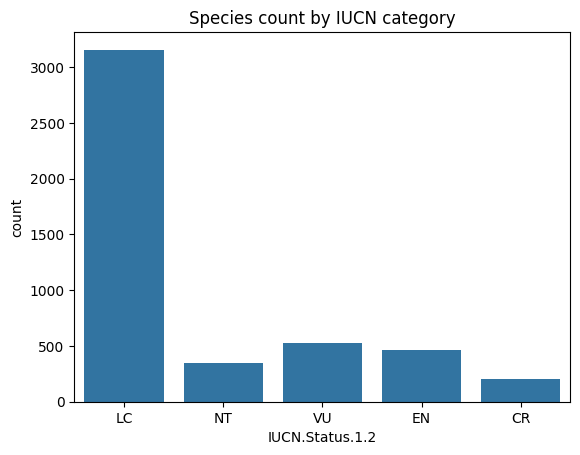

In [33]:
sns.countplot(x='IUCN.Status.1.2', data=trait_merged, order=['LC','NT','VU','EN','CR'])
plt.title('Species count by IUCN category')
plt.savefig('class_distribution.png', dpi=150)
plt.show()

### 2. Boxplot: `Log.Mass` vs `Threatened`

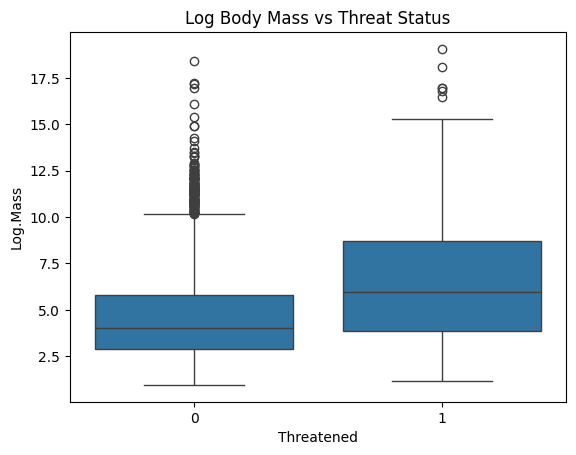

In [34]:
sns.boxplot(x='Threatened', y='Log.Mass',  data=trait_merged)
plt.title('Log Body Mass vs Threat Status')
plt.savefig('mass_vs_threat.png', dpi=150)
plt.show()

### 3. Boxplot: `Log.Range.Current` vs `Threatened`

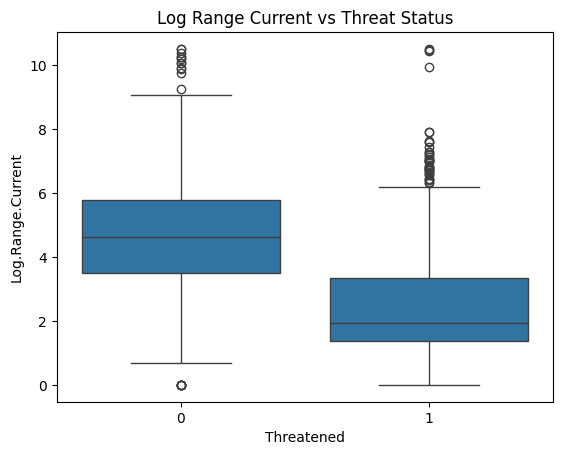

In [35]:
sns.boxplot(x='Threatened', y='Log.Range.Current',  data=trait_merged)
plt.title('Log Range Current vs Threat Status')
plt.savefig('range_vs_threat.png', dpi=150)
plt.show()

###  4. Corelation heatmapa

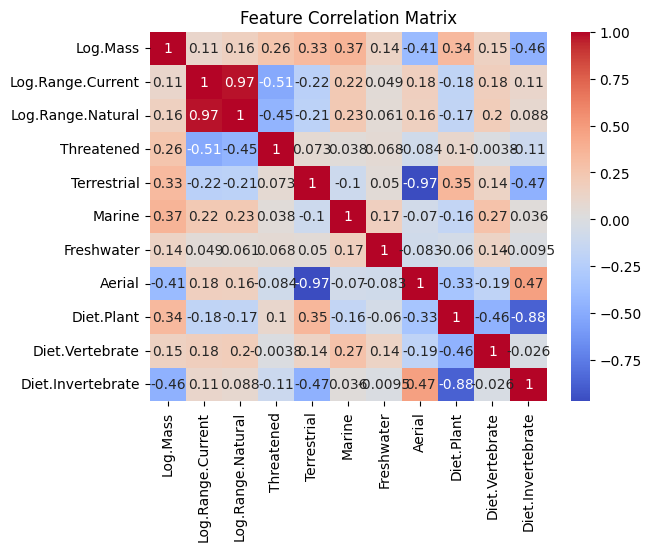

In [36]:
kor_cols = ['Log.Mass', 'Log.Range.Current', 'Log.Range.Natural', 'Threatened', 'Terrestrial', 'Marine', 'Freshwater', 'Aerial', 'Diet.Plant', 'Diet.Vertebrate', 'Diet.Invertebrate']
sns.heatmap(trait_merged[kor_cols].corr(),  annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

## Preliminary Conclusions Based on the Charts

1.  **Chart 1: Species Count by IUCN Category**

    It is evident that the LC (Least Concern) group predominates; the next two categories with similar results are VU (Vulnerable) and EN (Endangered), while CR (Critically Endangered) is the least common.
    We also see a significant class imbalance here, with a 3:1 ratio, which will affect the model predictions.

2. **Chart 2: Log Body Mass vs. Threat Status**

    As can be seen, body mass shows significant correlation with threat status, and the median for group 1 (threatened) is higher than for group 0 (unthreatened). This may suggest that larger mammals are more vulnerable to extinction.

3. **Chart 3: Log Range Current vs. Threat Status**

    Here, we can observe that the boxes do not overlap, and the median for Group 1 (threatened species) is closer to the lower bound, suggesting a strong correlation between Range and Threat.

4. **Chart 4: Feature Correlation Matrix**

    We can observe several relationships:
    - `Log.Range.Current` and `Log.Range.Natural` are very similar
    - `Log.Range.Current` and `Log.Range.Natural` have a strong correlation with `Threatened`
    - `Log.Mass` has a weaker correlation with `Threatened`

## PCA

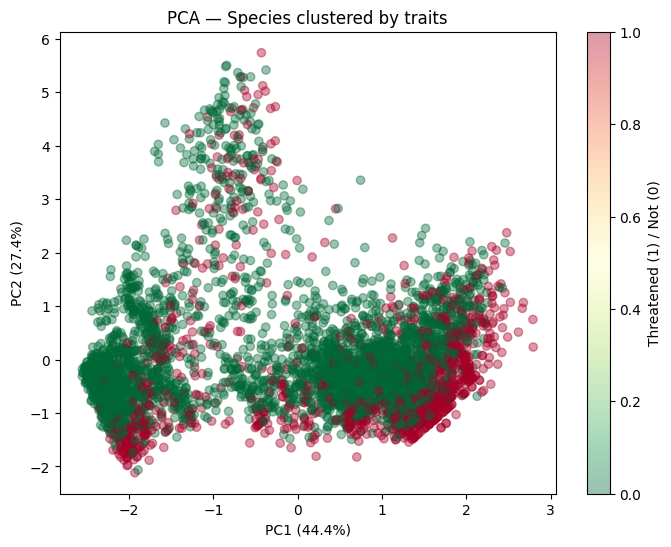

Variance explained: 71.7%


In [37]:
pca_features = ['Log.Mass', 'Log.Range.Current', 'Diet.Plant', 'Diet.Vertebrate', 'Diet.Invertebrate']
pca_df  = trait_merged[pca_features + ['Threatened']].dropna()

X_pca = StandardScaler().fit_transform(pca_df[pca_features])
pca= PCA(n_components=2)
components = pca.fit_transform(X_pca)

plt.figure(figsize=(8,6))
scatter = plt.scatter(components[:,0], components[:,1],
                      c=pca_df['Threatened'].values, cmap='RdYlGn_r', alpha=0.4)
plt.colorbar(scatter, label='Threatened (1) / Not (0)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA — Species clustered by traits')
plt.savefig('pca.png', dpi=150)
plt.show()

print(f'Variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%')


## Conclusions from PCA

1. Variance explained: 71.7%, which is a good result considering we’re looking at a 2D plot.
2. Clusters are visible in the lower right and lower left corners (Threatened(1) and Not(0)). PC1 explains 44.4% of the variance contained in the original 5 features
3. The second principal component, PC2, explains 27.4% of the variance; this is less because PC1 has already captured the dominant direction of variation.
4. The first two components together explain 71.7% of the variance, which means that by reducing the dimension from 5D to 2D, we lose approximately 30% of the variance.
5. The graph shows a partial separation of the red points from the green ones, indicating that biological traits carry a signal of threat but do not determine it on their own.
6. We can conclude from this that PCA provides us with a preliminary indication that the hypothesis may be correct, although this should be verified using machine learning models.


# Training Models


## Logistic Regresion

**Note:** Based on the correlation analysis shown in the heatmap, I decided not to include `Log.Range.Natural` in `model_features`. `Natural` and `Current` have a correlation coefficient of `0.97`, which means that including both of these features would make little difference and might even worsen the models’ performance.

I decided to keep `Log.Range.Current` because it aligns better with our hypothesis, in which we are examining the current impact of body mass and range on the risk of extinction.

In [38]:
model_features = ['Log.Mass', 'Log.Range.Current',
                  'Terrestrial', 'Marine', 'Freshwater', 'Aerial',
                  'Diet.Plant', 'Diet.Vertebrate', 'Diet.Invertebrate',
                  'Order.Encoded']

# indexes must be consistent
X = trait_merged[model_features].dropna()
y = trait_merged.loc[X.index, 'Threatened']

# stratify=y maintains the proportions of the classes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [39]:
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))
print(class_weight_dict)

{np.int64(0): np.float64(0.6699928724162509), np.int64(1): np.float64(1.970649895178197)}


In [40]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("--- Logistic Regresion ---")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1]):.3f}")

--- Logistic Regresion ---
              precision    recall  f1-score   support

           0       0.94      0.87      0.91       701
           1       0.70      0.84      0.76       239

    accuracy                           0.87       940
   macro avg       0.82      0.86      0.83       940
weighted avg       0.88      0.87      0.87       940

ROC-AUC: 0.919


## Random Forest

In [41]:
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("--- Random Forest ---")
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]):.3f}")

--- Random Forest ---
              precision    recall  f1-score   support

           0       0.89      0.94      0.91       701
           1       0.79      0.64      0.71       239

    accuracy                           0.87       940
   macro avg       0.84      0.79      0.81       940
weighted avg       0.86      0.87      0.86       940

ROC-AUC: 0.909


## Feature Importance


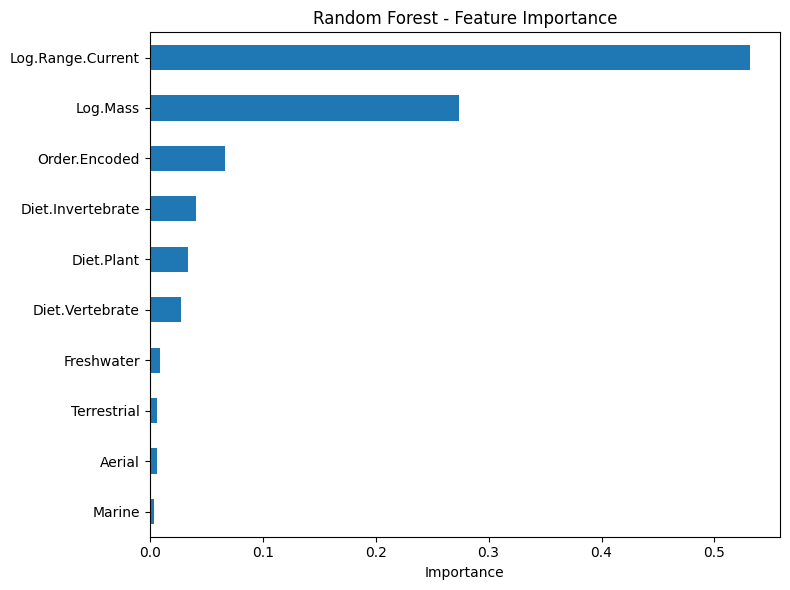

In [42]:
importances = pd.Series(rf.feature_importances_, index=model_features)
importances.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title("Random Forest - Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig('random_forest-feature_importance.png', dpi=150)

plt.show()

# Based on the chart above, we can **confirm the hypothesis**

## Chart Analysis
1. Top 3 traits:
- `Log.Range.Current` is approximately 0.6
- `Log.Mass` is 0.3
- `Order.Encoded` is less than 0.1

2. As can be seen, Range of Occurrence and Body Mass dominate over other traits; we may be particularly interested in their dominance over `Order.Encoded`, i.e., the taxonomic order of the mammal under study. This chart directly confirms the presented thesis.

## Confusion Matrix and ROC Curves

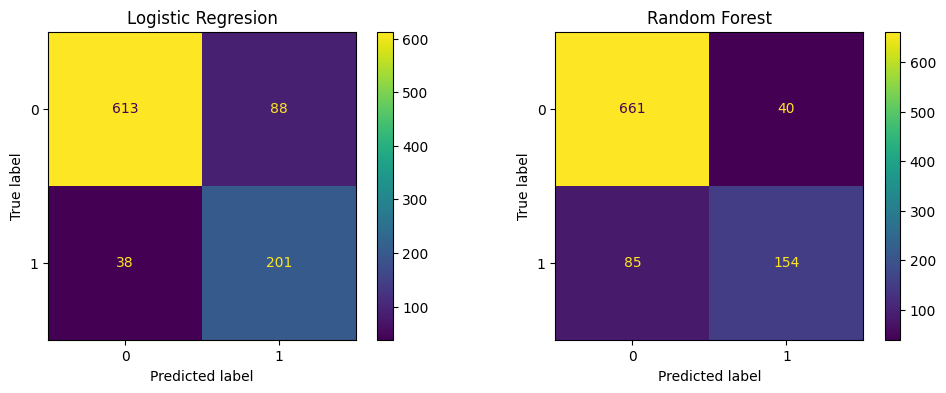

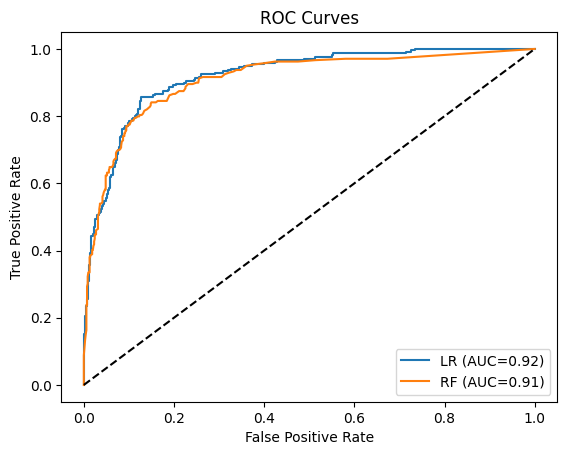

In [43]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[0])
axes[0].set_title('Logistic Regresion')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[1])
axes[1].set_title("Random Forest")

plt.savefig('confusion_matrices.png',  dpi=150)

# ROC Curves
fpr_lr,  tpr_lr, _ = roc_curve(y_test, lr.predict_proba(X_test_scaled)[:, 1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf.predict_proba(X_test)[:, 1])

plt.figure()
plt.plot(fpr_lr, tpr_lr,  label=f'LR (AUC={roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1]):.2f})')
plt.plot(fpr_rf, tpr_rf,  label=f'RF (AUC={roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]):.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.savefig('roc_curves.png', dpi=150)



##  Confusion Matrix Results

1. True Negative:
    - LR - 613
    - RF - 661
2. False Positive:
    - LR - 88
    - RF - 40
3.  False Negative:
    - LR - 38
    - RF - 85
4. True Positive:
    - LR - 201
    - RF - 154

**Summary:**
- Logistic Regression performs better in `recall` for class 1 (fewer missed endangered species) FN - 38 vs 85
- Random Forest performs better in class 0 `precision` (fewer false positives): FP - 40 vs 88

## Conclusions from the ROC Curve

In the ROC curve, the dashed line in the middle represents a model that guesses randomly with an AUC of 0.5

We aim for a model with an AUC of 1.0

The Logistic Regression model has an AUC of 0.92
The Random Forest model has an AUC of 0.91

It can be seen that the difference between them is minimal (it is 0.01)

This means that, according to the AUC metric, both models are very good.

#  Neural Network

In [53]:
# Definign model
class ExtinctionNET(nn.Module):
  def __init__(self, input_dim):
      super(ExtinctionNET, self).__init__()
      self.net = nn.Sequential(
          nn.Linear(input_dim, 64),
          nn.ReLU(),
          nn.Dropout(0.3),
          nn.Linear(64, 32),
          nn.ReLU(),
          nn.Dropout(0.2),
          nn.Linear(32, 1)
      )
  def forward(self, x):
    return  self.net(x)

In [54]:
#  Prepering tensors and DataLoader
X_train_nn = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_nn = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_nn = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
y_test_nn = torch.tensor(y_test.values, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train_nn, y_train_nn)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


In [55]:
# Penalty for False Negative is bigger than False Positive
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
pos_weight =  torch.tensor([n_neg / n_pos],  dtype=torch.float32)

In [56]:
# Training Loop
device = torch.device('cuda' if torch.cuda.is_available() else  'cpu')
torch.manual_seed(42)
nn_model = ExtinctionNET(input_dim=X_train_nn.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))
optimizer = torch.optim.Adam(nn_model.parameters(), lr=1e-3)

best_val_loss = float('inf')
patience, patience_counter = 5, 0
train_losses, val_losses = [], []

for epoch in range(100):
  # train
  nn_model.train()
  epoch_loss = 0
  for X_batch, y_batch in train_loader:
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
    optimizer.zero_grad()
    loss = criterion(nn_model(X_batch), y_batch)
    loss.backward()
    optimizer.step()
    epoch_loss += loss.item()
  train_losses.append(epoch_loss / len(train_loader))


  # validate
  nn_model.eval()
  with torch.no_grad():
    val_logits = nn_model(X_test_nn.to(device))
    val_loss =  criterion(val_logits, y_test_nn.to(device)).item()
  val_losses.append(val_loss)

  # early stopping
  if val_loss < best_val_loss:
    best_val_loss = val_loss
    best_weights = {k: v.clone()  for k, v in nn_model.state_dict().items()}
    patience_counter = 0
  else:
    patience_counter += 1
    if patience_counter  >= patience:
      print(f"Early stopping at epoch {epoch+1}")
      break
  print(f"Epoch {epoch+1} | Train Loss: {train_losses[-1]:.4f} | Val Loss: {val_loss:.4f}")
nn_model.load_state_dict(best_weights)


Epoch 1 | Train Loss: 0.8631 | Val Loss: 0.6112
Epoch 2 | Train Loss: 0.6232 | Val Loss: 0.5506
Epoch 3 | Train Loss: 0.5917 | Val Loss: 0.5319
Epoch 4 | Train Loss: 0.5771 | Val Loss: 0.5321
Epoch 5 | Train Loss: 0.5604 | Val Loss: 0.5336
Epoch 6 | Train Loss: 0.5667 | Val Loss: 0.5323
Epoch 7 | Train Loss: 0.5577 | Val Loss: 0.5268
Epoch 8 | Train Loss: 0.5543 | Val Loss: 0.5322
Epoch 9 | Train Loss: 0.5558 | Val Loss: 0.5273
Epoch 10 | Train Loss: 0.5424 | Val Loss: 0.5256
Epoch 11 | Train Loss: 0.5539 | Val Loss: 0.5259
Epoch 12 | Train Loss: 0.5557 | Val Loss: 0.5304
Epoch 13 | Train Loss: 0.5492 | Val Loss: 0.5229
Epoch 14 | Train Loss: 0.5412 | Val Loss: 0.5211
Epoch 15 | Train Loss: 0.5457 | Val Loss: 0.5222
Epoch 16 | Train Loss: 0.5380 | Val Loss: 0.5292
Epoch 17 | Train Loss: 0.5359 | Val Loss: 0.5231
Epoch 18 | Train Loss: 0.5453 | Val Loss: 0.5181
Epoch 19 | Train Loss: 0.5367 | Val Loss: 0.5203
Epoch 20 | Train Loss: 0.5322 | Val Loss: 0.5208
Epoch 21 | Train Loss: 0.5233

<All keys matched successfully>

## Wykres histroii uczenia

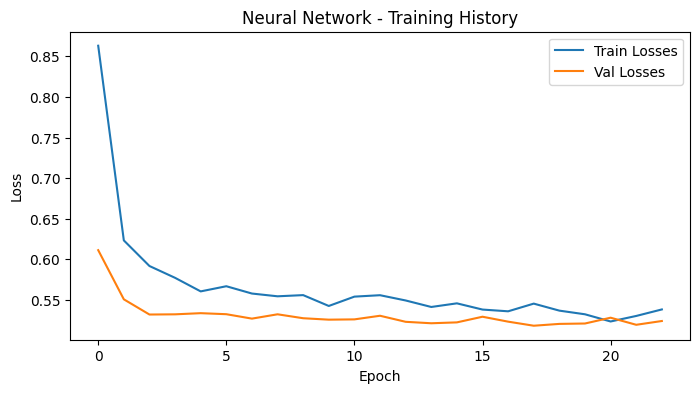

In [57]:
# training history plot
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Losses')
plt.plot(val_losses, label='Val Losses')
plt.title('Neural Network - Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.savefig('neural_network_train_historu.png', dpi=150)
plt.show()

## Evalutate

In [58]:
# evaluate:
nn_model.eval()
with torch.no_grad():
  logits = nn_model(X_test_nn.to(device)).cpu().numpy().flatten()

y_pred_nn_proba =  torch.sigmoid(torch.tensor(logits)).numpy()
y_pred_nn = (y_pred_nn_proba > 0.5).astype(int)

print("--- Neutral Network---")
print(classification_report(y_test, y_pred_nn))
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_nn_proba):.3f}")


--- Neutral Network---
              precision    recall  f1-score   support

           0       0.95      0.86      0.90       701
           1       0.68      0.87      0.76       239

    accuracy                           0.86       940
   macro avg       0.82      0.86      0.83       940
weighted avg       0.88      0.86      0.87       940

ROC-AUC: 0.925


## Sumary of ML models

In [63]:
report_lr = classification_report(y_test, y_pred_lr, output_dict=True)
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
report_nn = classification_report(y_test, y_pred_nn, output_dict=True)

results_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Neural Network'],
    'ROC-AUC': [
        roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:, 1]),
        roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, y_pred_nn_proba),
    ],
    'Precision for class 0': [
        classification_report(y_test, y_pred_lr, output_dict=True)['0']['precision'],
        classification_report(y_test, y_pred_rf, output_dict=True)['0']['precision'],
        classification_report(y_test, y_pred_nn, output_dict=True)['0']['precision']
        ],
    'Precision for class 1': [
        report_lr['1']['precision'],
        report_rf['1']['precision'],
        report_nn['1']['precision']
        ],
    'Recall for class 0': [
        report_lr['0']['recall'],
        report_rf['0']['recall'],
        report_nn['0']['recall']
    ],
    'Recall for class 1': [
        report_lr['1']['recall'],
        report_rf['1']['recall'],
        report_nn['1']['recall']
    ],
    'F1-score for class 0': [
        report_lr['0']['f1-score'],
        report_rf['0']['f1-score'],
        report_nn['0']['f1-score']
    ],
    'F1-score for class 1': [
        report_lr['1']['f1-score'],
        report_rf['1']['f1-score'],
        report_nn['1']['f1-score']
    ]
})
display(results_summary.round(3))

,Model,ROC-AUC,Precision for class 0,Precision for class 1,Recall for class 0,Recall for class 1,F1-score for class 0,F1-score for class 1
0,Logistic Regression,0.919,0.942,0.696,0.874,0.841,0.907,0.761
1,Random Forest,0.909,0.886,0.794,0.943,0.644,0.914,0.711
2,Neural Network,0.925,0.950,0.683,0.863,0.866,0.904,0.764


# Summary of the 3 models

Note: We are focusing on Class 1 (threatened species) because the thesis directly concerns them, and the aforementioned FN problem is more critical in their case.

It is better to misclassify a non-threatened species as threatened than the other way around.

1. In terms of AUC, all three perform almost identically (varying by about 0.01).
2. In terms of `Precision` (for Class 1, i.e., endangered species), **Random Forest** performs best.
3. In terms of `Recall`, **Neural Network** performs best.
4. In terms of `F1-score`, **Logistic Regression** performs best; it’s worth noting that in this case, the values are quite close to each other (especially NN and LR).

As you can see, each model excels in a different metric.

So the question remains: which one is best for protecting endangered species?

The answer is **Neural Network**. We must emphasize here the critical issue of false negatives: misclassifying an endangered species as non-endangered could lead to a potential downgrade of its status on the **IUCN** scale, which we want to avoid at all costs.

Here, we can observe the classic trade-off between precision and recall.

- By choosing **Logistic Regression** over **Neural Network**, we gain a little precision at the expense of recall. Precision will not increase drastically, so it is better to maximize recall
-  By choosing **Random Forest** over **Neural Network**, we do gain more precision (over 0.1), but unfortunately, recall decreases drastically (over 0.2).

Based on this analysis, I conclude that, of the models tested, the **Neural Network** is the best model for analyzing and protecting endangered species.

# Pre-order Analysis (Taxonomic Class Check)

In [60]:
top_orders = trait_merged['Order.1.2'].value_counts().head(8).index
results=[]
for order in top_orders:
  subset = trait_merged[trait_merged['Order.1.2'] == order]
  threatened_pct = subset['Threatened'].mean() * 100
  avg_mass = subset['Log.Mass'].mean()
  avg_range = subset['Log.Range.Current'].mean()
  results.append({
      'Order': order,
      'Threatened_%': round(threatened_pct, 1),
      'Avg_Log_Mass': round(avg_mass, 2),
      'Avg_Log_Range  ': round(avg_range, 2),
      'N': len(subset)
  })

order_df = pd.DataFrame(results).sort_values('Threatened_%', ascending=False)
display(order_df)

,Order,Threatened_%,Avg_Log_Mass,Avg_Log_Range,N
2,Primates,63.8,7.56,3.19,417
5,Cetartiodactyla,43.1,11.14,5.14,260
6,Diprotodontia,37.4,7.66,3.10,139
4,Carnivora,27.6,8.54,5.71,283
7,Lagomorpha,23.0,6.73,4.25,87
3,Eulipotyphla,20.4,2.75,3.64,373
1,Chiroptera,18.2,2.92,4.74,952
0,Rodentia,17.9,4.50,3.72,1862


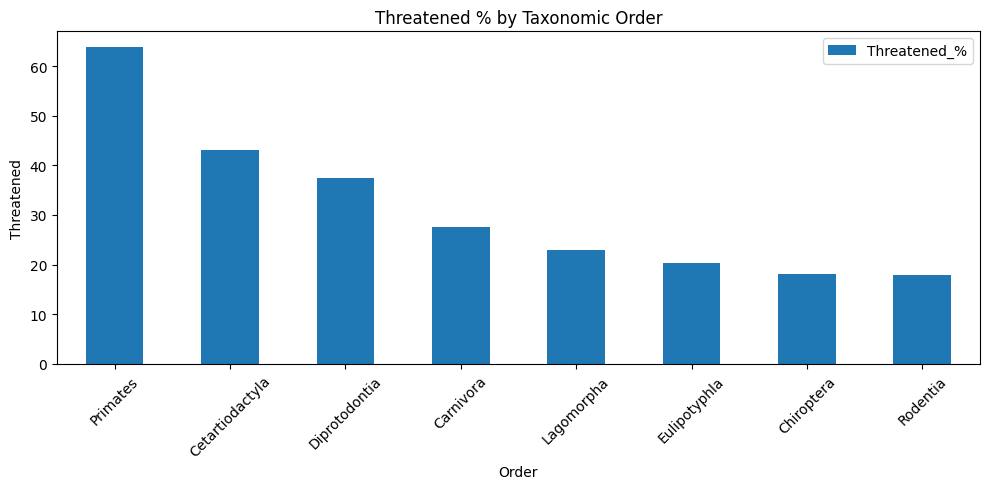

In [61]:
order_df.plot(x='Order', y='Threatened_%', kind='bar', figsize=(10, 5))
plt.title("Threatened % by Taxonomic Order")
plt.ylabel('Threatened')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('threatened_by_order.png', dpi=150)

# Findings from the Pre-order Analysis (Taxonomic Class Check)

The most threatened species, according to the `Threatened_%`  is **Primates**, at **64%**. They have an average score for `Avg_Log_Mass`, but it can be observed that the `Avg_Log_Range` coefficient is <ins>the 2nd lowest</ins> among all classes.

In second place is **Cetartiodactyla** with a score of **43%**. It can be seen that the `Avg_Log_Mass` coefficient is the highest among all classes. `Avg_Log_Range` is <ins>the second highest</ins>.

In third place is **Diprotodontia** (pl: Diprotodonts) with a score of **37%**. The `Avg_Log_Mass` coefficient is close to the middle, while `Avg_Log_Range` is <ins>the lowest recorded</ins> in the entire summary.

From this analysis, it can be concluded that greater mass (`Avg_Log_Mass`) and a smaller distribution range (`Avg_Log_Range`) increase the likelihood of a given taxonomic class being threatened.

HOWEVER, an important relationship emerges when analyzing the second-ranked group, namely **Cetartiodactyla**. It has the highest mass but also nearly the largest range (2nd place). This shows that our scale is not a perfect predictor, and because we define two classification criteria, a situation may arise in which one predictor dominates the other.

By analyzing this graph and the tables, one can conclude that taxonomic order does not explain the level of threat to mammals. Body mass and range are much more important.

In summary: Primates are not threatened simply because they are Primates or because they have a small range. This applies to each of the orders analyzed. This is clearly illustrated by the example of Cetartiodactyla given above.


# Final Conclusions / Summary

1. The feature importance analysis for Random Forest and the Taxonomic Class Check confirmed the validity of the stated hypothesis.
2. The feature importance analysis for Random Forest showed that the most important metrics are `Log.Range.Current` (0.5) and `Log.Mass` (0.3).
3. It is also worth noting the dramatic dominance of the top two features over the others (0.5/0.3 versus less than 0.1).
4. The significance of taxonomic order (the third most important feature at approximately 0.1) should not be overlooked, although it is significantly less important than Range or Mass.
5. The best model for classifying endangered species is the **Neural Network**, thanks to its optimal balance of `precision` and `recall`.
6. Limitations:
  - Small dataset (approximately 6k data points)
  - Only 3 classification models.
  - For `Order.Encoded`, I used `LabelEncoder`; perhaps a better alternative would be `OneHotEncoding`. My approach may have introduced an among the classes.
  - Some values of `Mass.g` were imputed (the `Mass.Method` flag)
7. What could be done with more time:
  - Test different model architectures (e.g., more hidden layers for neural networks)
  - Test other models (e.g., SVM, XGBoost, LightGBM)
  - Extend the model to a different dataset with other animal species (e.g., birds, fish, reptiles)